# GroupBy

* In Python's pandas library, the .groupby() function is a powerful tool for splitting a DataFrame into groups based on one or more criteria, applying a function to each group independently, and then combining the results into a new data structure.
* It is used alongside aggregate functions like COUNT(), SUM(), AVG(), MAX(), or MIN() to perform calculations on each group rather than the entire datase


In [1]:
import pandas as pd

In [2]:
df_cars=pd.read_csv("Car_sales.csv")

In [3]:
df_cars

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3.545,NaN,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,Volvo,S70,15.245,NaN,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,Volvo,V70,17.531,NaN,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,Volvo,C70,3.493,NaN,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357


In [4]:
df_cars['Model'].unique

<bound method Series.unique of 0      Integra
1           TL
2           CL
3           RL
4           A4
        ...   
152        V40
153        S70
154        V70
155        C70
156        S80
Name: Model, Length: 157, dtype: str>

In [5]:
df_cars.groupby('Vehicle_type')[['Sales_in_thousands',
                            'Price_in_thousands', 'Engine_size',
                            'Horsepower', 'Fuel_capacity']].mean()

,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
Vehicle_type,,,,,
Car,80.622293,26.319975,3.520000,186.400000,21.895000
Passenger,43.234345,27.763200,2.902586,185.793103,16.592241


# Pie Chart

In [6]:
import matplotlib.pyplot as plt

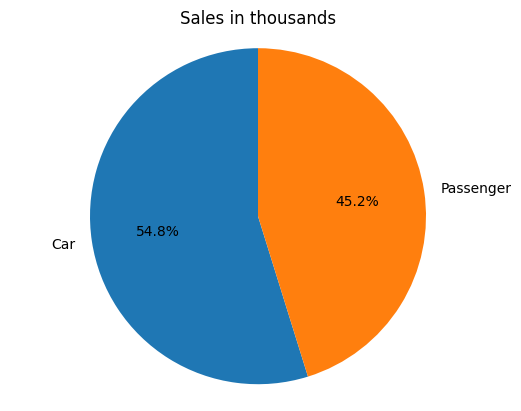

In [7]:
Sales_in_thousands=df_cars.groupby('Vehicle_type')['Engine_size'].mean()
plt.pie(
    Sales_in_thousands,
    labels=Sales_in_thousands.index,
    autopct='%.1f%%',
    startangle=90
)

plt.title('Sales in thousands')                           
plt.axis('equal')  # Ensures pie chart is a circle
plt.show()


# Scatter Chart

<Axes: xlabel='Vehicle_type', ylabel='Fuel_capacity'>

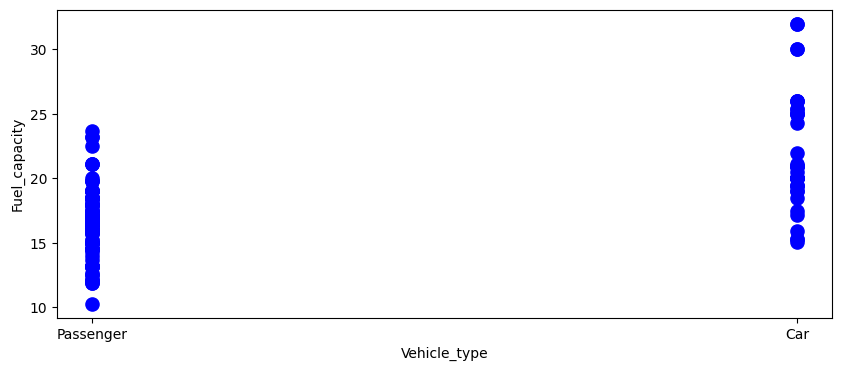

In [8]:
df_cars.plot(kind='scatter',x='Vehicle_type',y='Fuel_capacity',figsize=(10,4),color = 'blue', s=90)

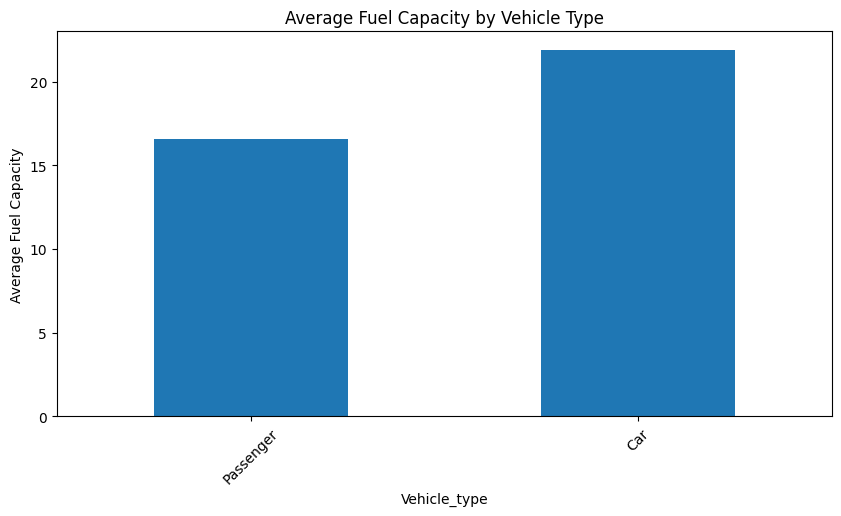

In [9]:
avg = df_cars.groupby('Vehicle_type')['Fuel_capacity'].mean().sort_values()

plt.figure(figsize=(10,5))
avg.plot(kind='bar')

plt.xticks(rotation=45)
plt.ylabel('Average Fuel Capacity')
plt.title('Average Fuel Capacity by Vehicle Type')
plt.show()

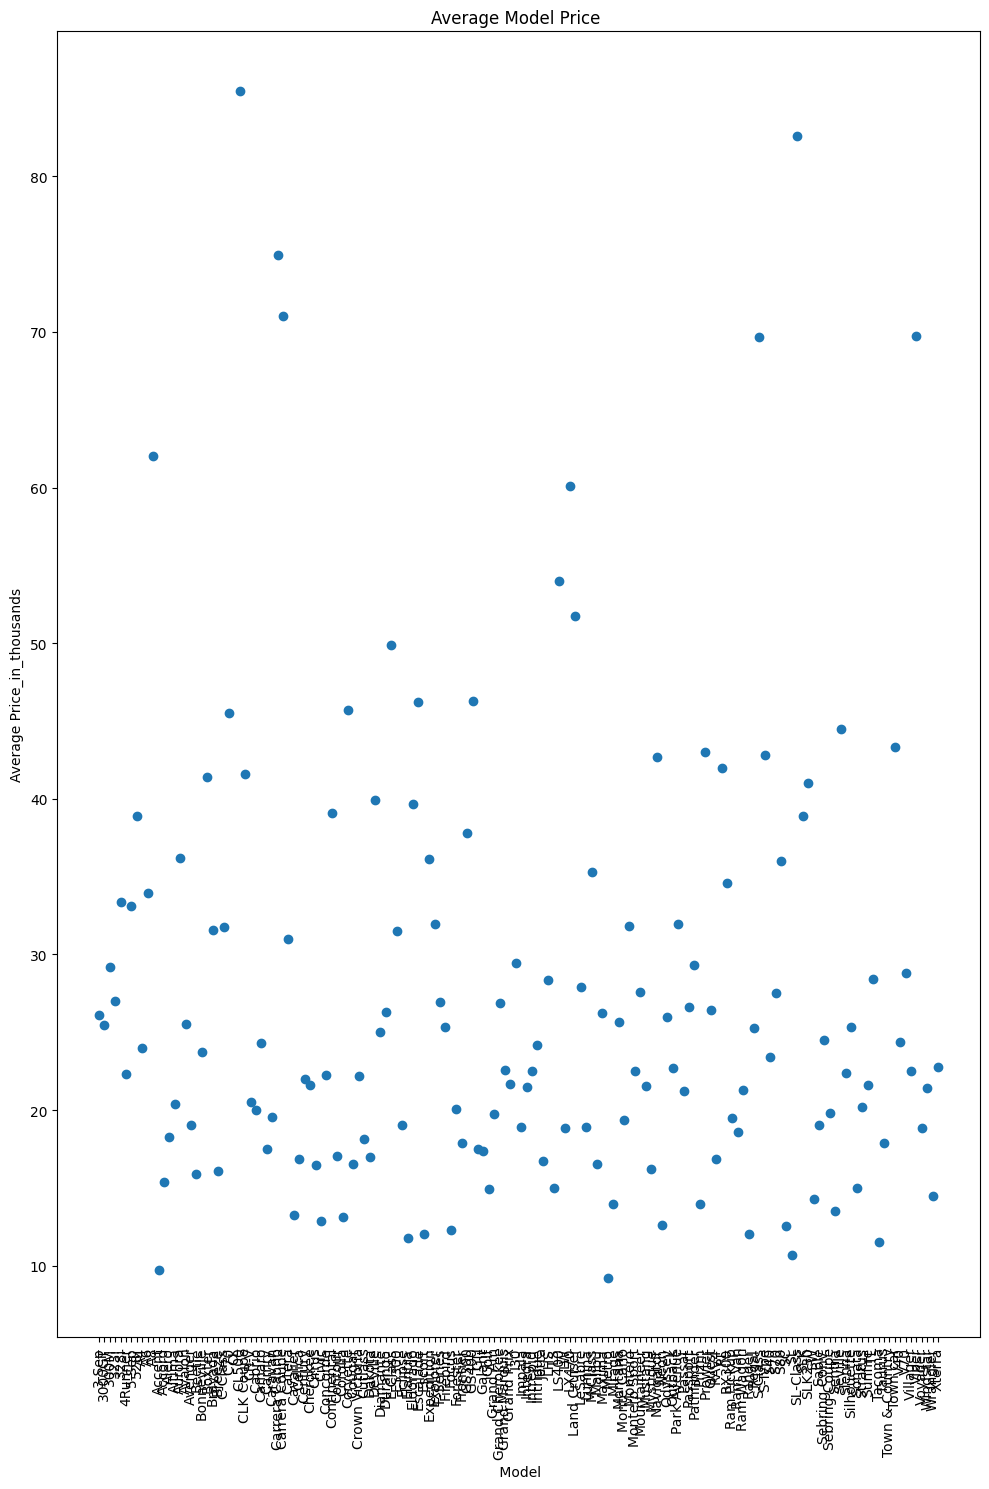

In [10]:
Sales_in_thousands = df_cars.groupby('Model')['Price_in_thousands'].mean()

plt.figure(figsize=(10,15))

plt.scatter(
    Sales_in_thousands.index,   # x-axis
    Sales_in_thousands.values   # y-axis
)

plt.xticks(rotation=90)
plt.xlabel(' Model')
plt.ylabel('Average Price_in_thousands')
plt.title('Average Model Price ')

plt.tight_layout()
plt.show()

## 3. Strip Plot (Better Scatter Alter#native)

In [11]:
import seaborn as sns

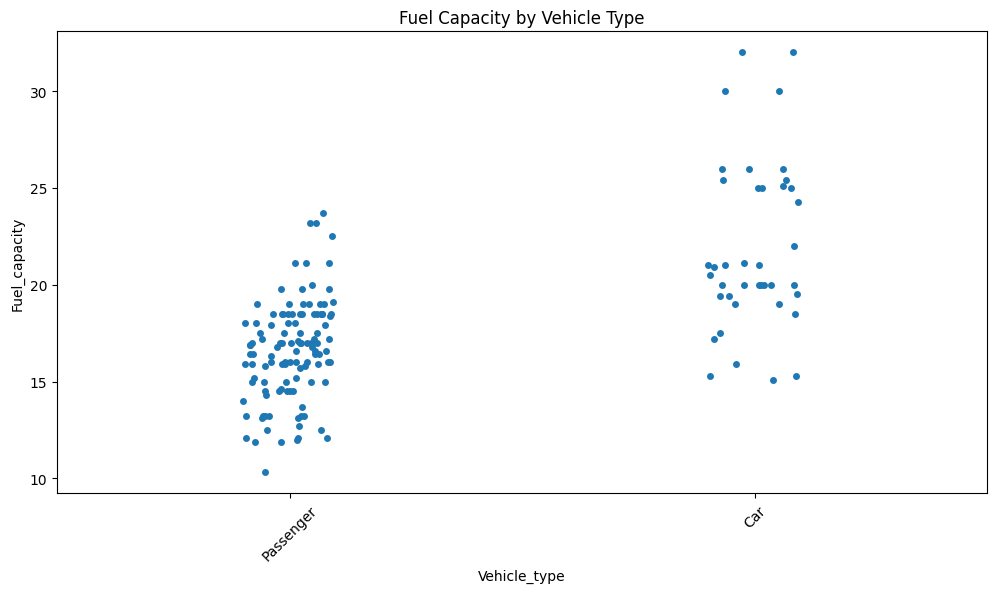

In [12]:
plt.figure(figsize=(12,6))
sns.stripplot(x='Vehicle_type', y='Fuel_capacity', data=df_cars)

plt.xticks(rotation=45)
plt.title('Fuel Capacity by Vehicle Type')
plt.show()

## Swarm Plot (Even Better Visualization)

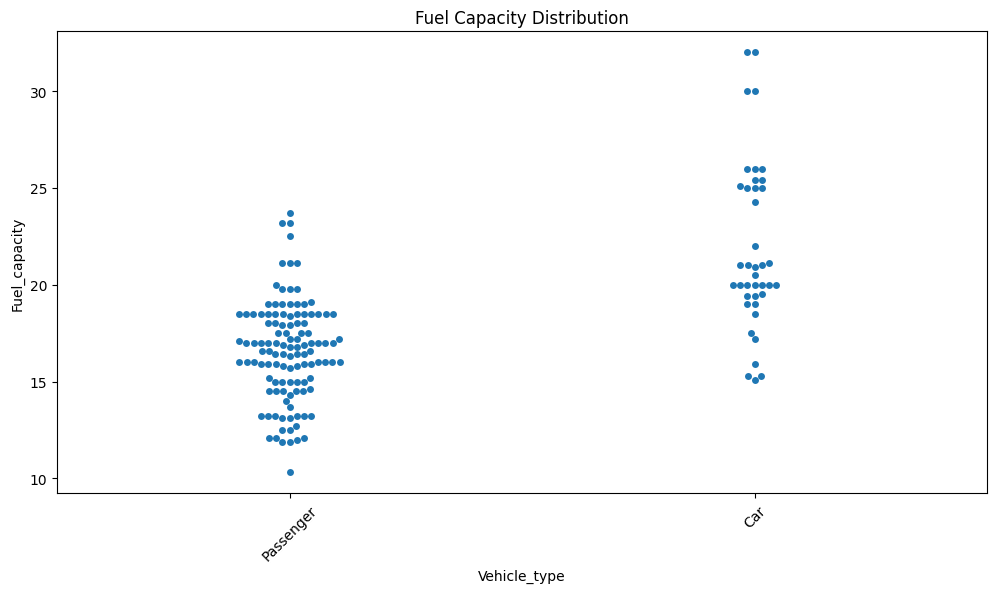

In [13]:
plt.figure(figsize=(12,6))
sns.swarmplot(x='Vehicle_type', y='Fuel_capacity', data=df_cars)

plt.xticks(rotation=45)
plt.title('Fuel Capacity Distribution')
plt.show()

# Bar Chart

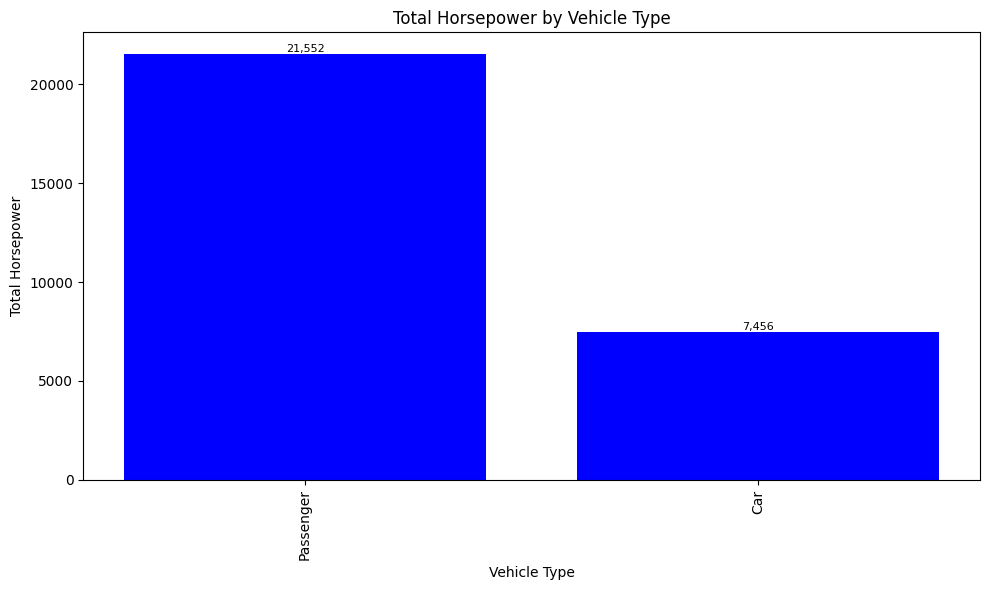

In [14]:
Price_in_thousands = df_cars.groupby('Vehicle_type')['Horsepower'].sum().sort_values(ascending=False)

# Set figure size
plt.figure(figsize=(10, 6))

# Create bar chart
bars = plt.bar(Price_in_thousands.index,Price_in_thousands.values, color='blue')

# Rotate x-axis labels for readability
plt.xticks(rotation=90)
plt.xlabel('Vehicle Type')
plt.ylabel('Total Horsepower')
plt.title('Total Horsepower by Vehicle Type')
# Add value labels on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

# Outlet Establishmant

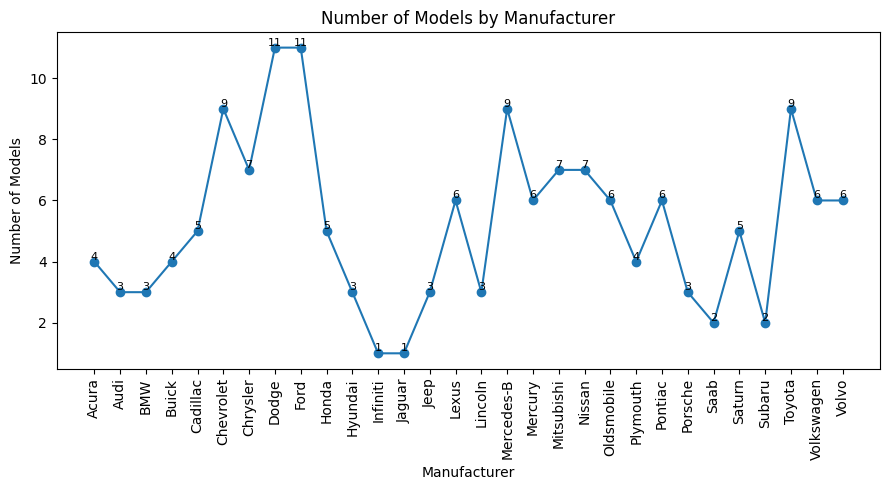

In [15]:
model_count = df_cars.groupby('Manufacturer')['Model'].count().sort_index()

plt.figure(figsize=(9, 5))

plt.plot(
    model_count.index,
    model_count.values,
    marker='o',
    linestyle='-'
)

plt.xticks(rotation=90)
plt.xlabel('Manufacturer')
plt.ylabel('Number of Models')
plt.title('Number of Models by Manufacturer')

# Add value labels
for x, y in zip(model_count.index, model_count.values):
    plt.text(x, y, f'{y}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Histogram

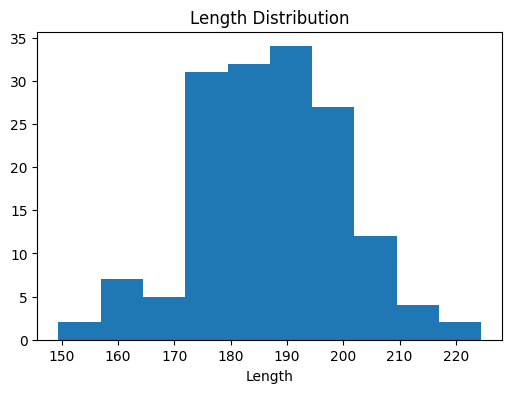

In [16]:
plt.figure(figsize=(6,4))

plt.hist(df_cars['Length'], bins=10)

plt.xlabel('Length')
plt.title('Length Distribution')

plt.show()

# Donut Chart

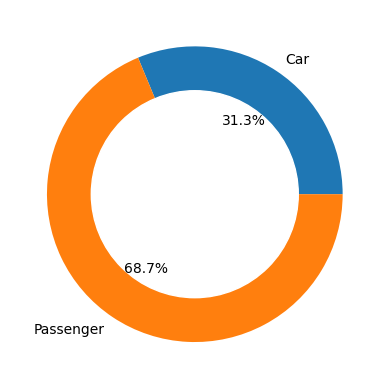

In [17]:
import matplotlib.pyplot as plt

data = df_cars.groupby('Vehicle_type')['Fuel_capacity'].sum()

plt.pie(data, labels=data.index, autopct='%.1f%%')
plt.gca().add_artist(plt.Circle((0,0), 0.7, color='white'))

plt.show()

# Stacked bar chart

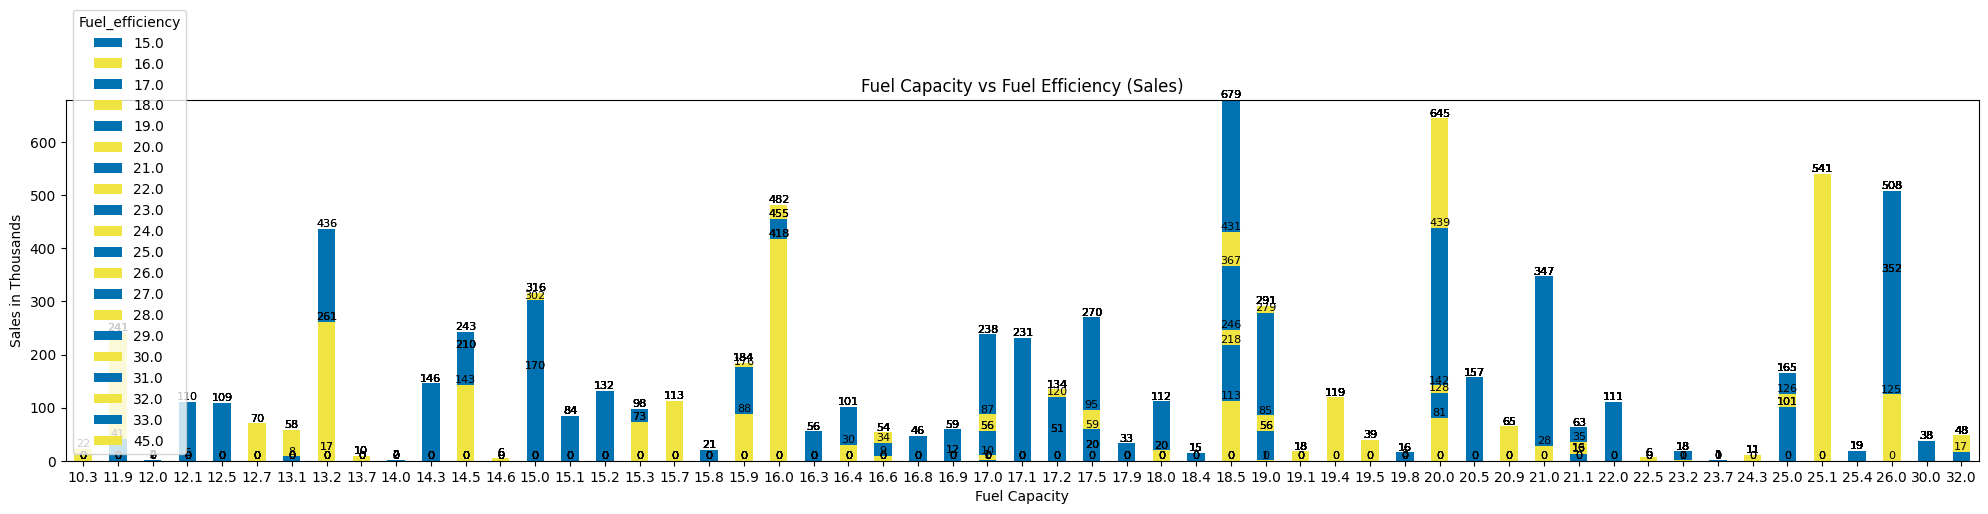

In [18]:
import matplotlib.pyplot as plt

# 1. Prepare data
data = df_cars.groupby(['Fuel_capacity', 'Fuel_efficiency'])['Sales_in_thousands'].sum().unstack()

# 2. Plot
ax = data.plot(
    kind='bar',
    stacked=True,
    figsize=(20, 5),
    color=['#0072B2', '#F0E442'],
    rot=0
)

# 3. Add labels inside bars
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', label_type='edge', fontsize=8)

# 4. Title
plt.title('Fuel Capacity vs Fuel Efficiency (Sales)')
plt.xlabel('Fuel Capacity')
plt.ylabel('Sales in Thousands')

plt.tight_layout()
plt.show()

# horizontal bar chart

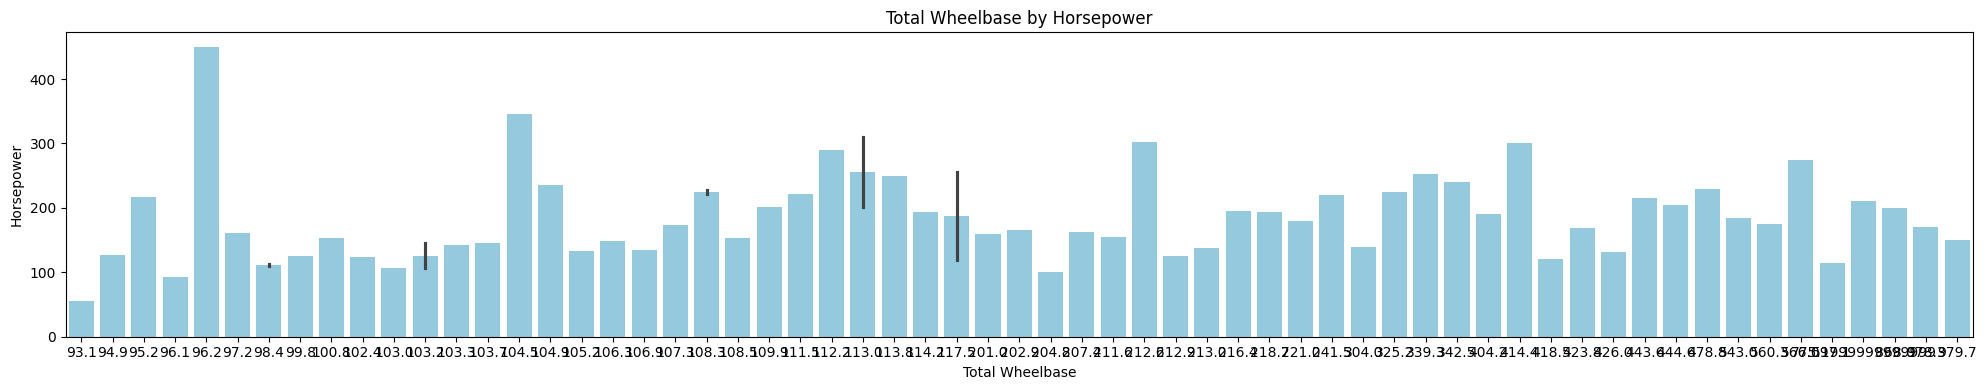

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
Sales_in_thousands = (
    df_cars.groupby('Horsepower')['Wheelbase']
    .sum()
    .reset_index()
    .sort_values('Wheelbase', ascending=False)
)

# Set figure size
plt.figure(figsize=(20, 4))

# Create horizontal bar chart
ax = sns.barplot(
    x='Wheelbase',
    y='Horsepower',
    data=Sales_in_thousands,
    color='skyblue'
)

# Titles and labels
plt.title('Total Wheelbase by Horsepower')
plt.xlabel('Total Wheelbase')
plt.ylabel('Horsepower')

plt.tight_layout()
plt.show()

In [28]:
import os

In [29]:
os.getcwd()

'C:\\Users\\LENOVO\\Python Practice'

In [ ]:
os.chdir(r"